In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn


In [ ]:
from sklearn.datasets import load_iris


In [6]:
iris  = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [7]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
df["target"] = iris.target
df.target

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [9]:
x = df.drop("target",axis = 1)
y = df.target

In [10]:
from sklearn.model_selection import train_test_split


x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2)

In [11]:
model = RandomForestClassifier(n_estimators=10)

model.fit(x_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
score = model.score(x_test, y_test)
print("Accuracy with 10 trees:", score)

Accuracy with 10 trees: 0.9666666666666667


In [13]:
y_predicted = model.predict(x_test)

In [14]:
cm = confusion_matrix(y_test, y_predicted)
cm

array([[11,  0,  0],
       [ 0,  5,  1],
       [ 0,  0, 13]])

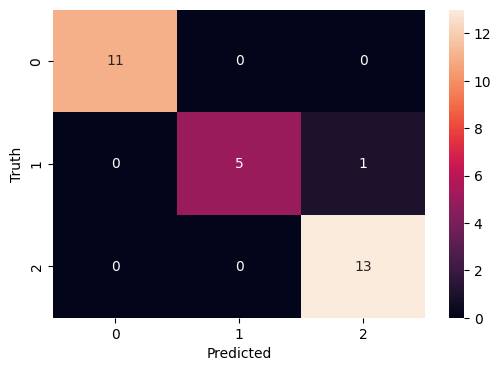

In [15]:
plt.figure(figsize=(6,4))

sn.heatmap(cm, annot=True)

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [16]:
scores = []

for n in range(1, 101):
    model = RandomForestClassifier(n_estimators=n)

    model.fit(x_train, y_train)

    score = model.score(x_test, y_test)

    scores.append((n, score))
for n, score in scores:
    print("Trees:", n, " Score:", score)

Trees: 1  Score: 0.9666666666666667
Trees: 2  Score: 0.9333333333333333
Trees: 3  Score: 0.9333333333333333
Trees: 4  Score: 0.9666666666666667
Trees: 5  Score: 0.9666666666666667
Trees: 6  Score: 0.9666666666666667
Trees: 7  Score: 0.9666666666666667
Trees: 8  Score: 0.9333333333333333
Trees: 9  Score: 0.9666666666666667
Trees: 10  Score: 0.9333333333333333
Trees: 11  Score: 0.9666666666666667
Trees: 12  Score: 0.9666666666666667
Trees: 13  Score: 0.9666666666666667
Trees: 14  Score: 0.9333333333333333
Trees: 15  Score: 0.9666666666666667
Trees: 16  Score: 0.9666666666666667
Trees: 17  Score: 0.9333333333333333
Trees: 18  Score: 0.9666666666666667
Trees: 19  Score: 0.9333333333333333
Trees: 20  Score: 0.9666666666666667
Trees: 21  Score: 0.9333333333333333
Trees: 22  Score: 0.9333333333333333
Trees: 23  Score: 0.9666666666666667
Trees: 24  Score: 0.9333333333333333
Trees: 25  Score: 0.9333333333333333
Trees: 26  Score: 0.9333333333333333
Trees: 27  Score: 0.9666666666666667
Trees: 28 

In [17]:
best = max(scores, key=lambda x: x[1])

print("Best Number of Trees:", best[0])
print("Best Score:", best[1])

Best Number of Trees: 1
Best Score: 0.9666666666666667


In [19]:
import pickle
with open("random_forest.pkl","wb") as file:
    pickle.dump(model,file)

In [ ]:
with open('random_forest.pkl','rb') as file:
    mp = pickle.load(file)